# 5.4.1 状态路径与概率分布的两种推进

## 学习目标与先修知识

能写出马尔可夫（Markov）与时间齐次（time-homogeneous）假设，按行向量（vector）传播分布（distribution），用指定均匀数抽取路径，并对照多路径频率的不确定性。

先修：5.3 的条件概率（conditional probability）；第 3.1 章矩阵乘法（matrix multiplication）与状态（state）/观测（observation）区别。 [复习上一节](../03-条件概率与贝叶斯更新/02-固定未知量的高斯更新.ipynb)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

一个细胞只能处于静息或活跃状态，群体活跃比例却可以是 0.34。这两种描述如何来自同一套切换规则？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
matrix=np.array([[.8,.2],[.1,.9]]);p=np.array([1.,0.])
display(Markdown(show_table(['步','静息概率','活跃概率'],[(0,*p),(1,*(p@matrix)),(2,*(p@matrix@matrix))])))

| 步 | 静息概率 | 活跃概率 |
| --- | --- | --- |
| 0 | 1 | 0 |
| 1 | 0.8 | 0.2 |
| 2 | 0.66 | 0.34 |

## 模型假设

状态 0 静息、1 活跃；观察间隔一个周期。转移矩阵（transition matrix） P=[[0.8,0.2],[0.1,0.9]] 的每行从一个当前状态出发。每个细胞满足相同规则，细胞间独立，不考虑相互作用或隐藏持久记忆。时间齐次表示每周期的矩阵（matrix）相同。随机种子（random seed）为 5401，生成 B=200 条独立路径，每条 40 步。

## 数学解释与推导

随机过程（stochastic process）是按时间索引的一组随机变量（random variable） X0,X1,…；一条路径是它们在一次实验中的实现。马尔可夫假设为
$$P(X_{n+1}=j\mid X_n=i,X_{n-1},\ldots)=P(X_{n+1}=j\mid X_n=i).$$
它是给定当前状态后不再需要过去，不是相邻时刻独立。若当前标签遗漏持续作用的内部变量，假设可能失效。

定义 Pᵢⱼ 为从 i 到 j 的条件概率；Pᵢⱼ≥0，每行和为 1。由全概率（probability）公式
$$p_{n+1,j}=\sum_i p_{n,i}P_{ij},\qquad p_{n+1}=p_nP.$$
行向量右乘是本篇统一约定，列和一般不必为 1。它推进整个分布，不涉及随机抽取。

单条路径在当前行做抽样：将概率累计成 [0,c1)、[c1,c2)、…，均匀数 u∈[0,1) 落在哪段就选哪个状态。恰等于内部边界属于右侧区间。不同细胞的同一时刻标签可看作 Bernoulli 样本，因此活跃频率标准差（standard deviation）为 √(p(1−p)/B)。不同时间的同一路径相关，不能把 200×40 个标签统称为独立细胞。

## 核心实现

把公式中的量和顺序写成可检查的计算。

In [3]:
def propagate(matrix, initial, steps):
    values = [list(initial)]
    for _ in range(steps):
        current = values[-1]
        values.append([sum(current[i]*matrix[i][j] for i in range(len(current))) for j in range(len(current))])
    return values


def path_from_uniforms(matrix, initial_state, uniforms):
    states = [initial_state]
    for u in uniforms:
        cumulative = 0.0
        for j,p in enumerate(matrix[states[-1]]):
            cumulative += p
            if u < cumulative:
                states.append(j)
                break
        else:
            states.append(len(matrix)-1)
    return states

## 对照实验

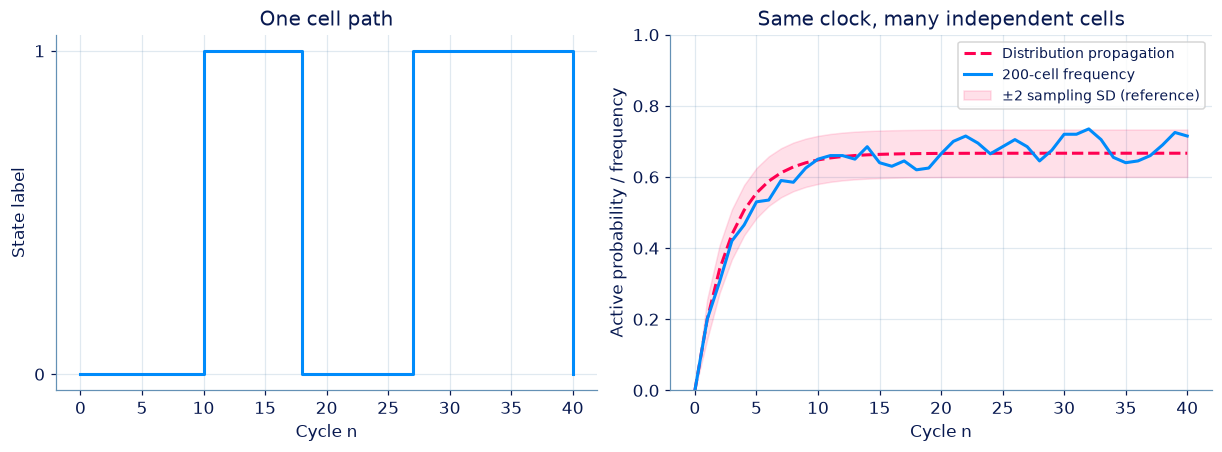

| n | 理论活跃概率 | 经验频率 | 频率标准差 |
| --- | --- | --- | --- |
| 0 | 0 | 0 | 0 |
| 1 | 0.2 | 0.2 | 0.0282843 |
| 2 | 0.34 | 0.305 | 0.0334963 |
| 20 | 0.666135 | 0.665 | 0.0333466 |
| 40 | 0.666666 | 0.715 | 0.0333333 |

根种子 5401 ；独立路径数 200 ；PCG64；NumPy 2.5.3


In [4]:
P=[[.8,.2],[.1,.9]];steps=40;repeats=200;root_seed=5401
streams=np.random.SeedSequence(root_seed).spawn(repeats)
paths=np.array([path_from_uniforms(P,0,np.random.Generator(np.random.PCG64(s)).random(steps)) for s in streams])
theory=np.array(propagate(P,[1,0],steps));frequency=paths.mean(axis=0)
scale=np.sqrt(theory[:,1]*(1-theory[:,1])/repeats);n=np.arange(steps+1)
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].step(n,paths[0],where='post',color=BLUE)
axes[0].set(xlabel='Cycle n',ylabel='State label',yticks=[0,1],title='One cell path')
axes[1].plot(n,theory[:,1],color=PINK,ls='--',label='Distribution propagation')
axes[1].plot(n,frequency,color=BLUE,label='200-cell frequency')
axes[1].fill_between(n,np.maximum(0,theory[:,1]-2*scale),np.minimum(1,theory[:,1]+2*scale),color=PINK,alpha=.12,label='±2 sampling SD (reference)')
axes[1].set(xlabel='Cycle n',ylabel='Active probability / frequency',ylim=(0,1),title='Same clock, many independent cells');axes[1].legend(fontsize=9)
plt.show()
display(Markdown(show_table(['n','理论活跃概率','经验频率','频率标准差'],[(i,theory[i,1],frequency[i],scale[i]) for i in [0,1,2,20,40]])))
print('根种子',root_seed,'；独立路径数',repeats,'；PCG64；NumPy',np.__version__)

## 结果解释

左图只能为 0 或 1；右图是相同时间跨细胞的比例。阴影表示每个时刻理论频率上下两个标准差的范围，并截在 [0,1] 内。它帮助比较各时刻的频率波动；小样本或概率接近端点时，这个范围的覆盖比例会变化。

### 独立核对

两态概率递推可独立化成 p_active[n+1]=0.2+0.7*p_active[n]，给出闭式；随机检查仅选预先指定终点。

In [5]:
np.testing.assert_allclose(theory[:3],[[1,0],[.8,.2],[.66,.34]])
np.testing.assert_allclose(theory.sum(axis=1),1,atol=1e-12)
assert path_from_uniforms(P,0,[.7,.8,.05])==[0,0,1,0]
closed=np.array([2/3*(1-.7**n) for n in range(steps+1)])
np.testing.assert_allclose(theory[:,1],closed)
assert abs(frequency[-1]-theory[-1,1])<5*scale[-1]
print('逐步手算、归一化、抽样边界、二态闭式与终点频率一致。')

逐步手算、归一化、抽样边界、二态闭式与终点频率一致。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/05-04-随机过程与马尔可夫模型/explore/)：改变一个条件，比较实现、分布与理论参照，再返回完整推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：从细胞切换规则传播概率

细胞每周期按给定马尔可夫（Markov）转移矩阵（transition matrix）切换。计算整个群体的理论状态（state）分布（distribution），不能返回单条随机路径。

**函数与代码模板**

```python
def solve(
    matrix: list[list[float]],
    initial: list[float],
    steps: int,
) -> list[list[float]]:
    # 依据题目规则计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `matrix` | `list[list[float]]` | 行随机矩阵（matrix）；第 i 行给出从状态 i 到各状态的概率（probability）。 | 1 |
| `initial` | `list[float]` | 时刻 0 的行概率向量（vector）。 | 1 |
| `steps` | `int` | 传播步数。 | 步 |

**返回值**

直接返回 distributions（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `distributions` | `list[list[float]]` | 包含时刻 0，外层按时刻，内层按状态编号。 | 1 |

**计算规则**

p_next[j]=Σᵢp[i]*matrix[i][j]；同步更新所有分量；包含初始分布。

**约束与边界**

- 所有数值有限；不修改输入（input）列表。
- 方阵维数 1—5；非负且每行和为 1（误差≤1e−12）；initial 等维、非负、和为 1；0≤steps≤100。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| matrix | 行随机矩阵（matrix）；第 i 行给出从状态 i 到各状态的概率（probability）。 | [[0.8, 0.2], [0.1, 0.9]] | 1 |
| initial | 时刻 0 的行概率向量（vector）。 | [1, 0] | 1 |
| steps | 传播步数。 | 2 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
matrix = [[0.8, 0.2], [0.1, 0.9]]
initial = [1, 0]
steps = 2

result = solve(matrix, initial, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| distributions | 包含时刻 0，外层按时刻，内层按状态编号。 | [[1, 0], [0.8, 0.2], [0.6600000000000001, 0.3400000000000001]] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[1, 0],
                   [0.8, 0.2],
                   [0.6600000000000001, 0.3400000000000001]]
```

**样例解释**

前两步为 [0.8,0.2]、[0.66,0.34]；初始 [1,0] 也保留在返回列表中。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：从细胞切换规则传播概率](http://127.0.0.1:8000/chapters/05-04-%E9%9A%8F%E6%9C%BA%E8%BF%87%E7%A8%8B%E4%B8%8E%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E6%A8%A1%E5%9E%8B/practice/?question=p05-propagation)

### 第 2 题 · Python 计算题：由指定随机数生成一条路径

给定每一步已抽出的均匀数，按当前状态（state）所在行做逆累计抽样。这样可逐步核对路径，而不依赖某一随机库版本。

**函数与代码模板**

```python
def solve(
    matrix: list[list[float]],
    initial_state: int,
    uniforms: list[float],
) -> list[int]:
    # 依据题目规则计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `matrix` | `list[list[float]]` | 行随机矩阵（matrix）；第 i 行给出从状态 i 到各状态的概率（probability）。 | 1 |
| `initial_state` | `int` | 起始状态的零起始下标。 | 1 |
| `uniforms` | `list[float]` | 每步使用一个 [0,1) 内的数，按顺序使用。 | 1 |

**返回值**

直接返回 states（list[int]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[int]` | 起始状态及每步抽中的状态。 | 1 |

**计算规则**

扫描当前行，从第 0 列累计概率，选第一个 cumulative>u 的列；等于边界时进入右侧区间。若仅因浮点舍入没有命中，选最后一列。

**约束与边界**

- 所有数值有限；不修改输入（input）列表。
- 矩阵符合行随机矩阵条件，维数 1—5；initial_state 是合法下标；0—100 个均匀数，均在 [0,1)。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| matrix | 行随机矩阵（matrix）；第 i 行给出从状态 i 到各状态的概率（probability）。 | [[0.8, 0.2], [0.1, 0.9]] | 1 |
| initial_state | 起始状态的零起始下标。 | 0 | 1 |
| uniforms | 每步使用一个 [0,1) 内的数，按顺序使用。 | [0.7, 0.8, 0.05] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
matrix = [[0.8, 0.2], [0.1, 0.9]]
initial_state = 0
uniforms = [0.7, 0.8, 0.05]

result = solve(matrix, initial_state, uniforms)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| states | 起始状态及每步抽中的状态。 | [0, 0, 1, 0] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0, 0, 1, 0]
```

**样例解释**

依次抽到 0、1、0，连同起点返回 [0,0,1,0]。u=0.8 位于右侧区间，不能仍选状态 0。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：由指定随机数生成一条路径](http://127.0.0.1:8000/chapters/05-04-%E9%9A%8F%E6%9C%BA%E8%BF%87%E7%A8%8B%E4%B8%8E%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E6%A8%A1%E5%9E%8B/practice/?question=p05-path)

### 第 3 题 · 多项选择题：马尔可夫假设省略了什么

用当前细胞标签预测下一周期标签，采用时间齐次（time-homogeneous）马尔可夫（Markov）模型（model）。哪些正确？

- **A.** 所有相邻时刻都独立。
- **B.** 所有时刻使用相同转移矩阵（transition matrix）。
- **C.** 即使遗漏持续作用的内部变量，该假设也必然成立。
- **D.** 给定当前状态（state）后，过去标签不再额外改变下一步分布（distribution）。

[作答：马尔可夫假设省略了什么](http://127.0.0.1:8000/chapters/05-04-%E9%9A%8F%E6%9C%BA%E8%BF%87%E7%A8%8B%E4%B8%8E%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E6%A8%A1%E5%9E%8B/practice/?question=p05-markov-assumption)

### 第 4 题 · 单项选择题：概率为 0.34 的状态怎样出现

第二周期活跃态概率（probability）为 0.34。哪项解释正确？

- **A.** 大量独立路径在该时刻的活跃频率可近似 0.34，仍有抽样波动。
- **B.** 观察到一个静息细胞即可否定模型（model）。
- **C.** 每个细胞处于 0.34 个活跃态。
- **D.** 一条路径一定在活跃态停留 34% 的时间。

[作答：概率为 0.34 的状态怎样出现](http://127.0.0.1:8000/chapters/05-04-%E9%9A%8F%E6%9C%BA%E8%BF%87%E7%A8%8B%E4%B8%8E%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E6%A8%A1%E5%9E%8B/practice/?question=p05-path-distribution)

### 第 5 题 · 多项选择题：如何检查一个转移矩阵

采用行随机矩阵（matrix）约定，以下哪些是必要检查？

- **A.** 矩阵行数与状态（state）数相同。
- **B.** 各元素非负。
- **C.** 每行和为 1。
- **D.** 每列和必须也为 1。

[作答：如何检查一个转移矩阵](http://127.0.0.1:8000/chapters/05-04-%E9%9A%8F%E6%9C%BA%E8%BF%87%E7%A8%8B%E4%B8%8E%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E6%A8%A1%E5%9E%8B/practice/?question=p05-stochastic-matrix)

**进一步阅读**

[MIT 6.041 讲义](https://ocw.mit.edu/courses/6-041-probabilistic-systems-analysis-and-applied-probability-fall-2010/pages/lecture-notes/)：第 16—18 讲：Markov chains。